In [2]:

import pandas as pd 
import joblib 
import numpy as np 
import shap
import matplotlib.pyplot as plt 

d:\Ai Engineering bootcamp\Deep_learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv("../data/telco_clean.csv")
X =df.drop("Churn Label",axis=1)
y = df["Churn Label"].map({"No":0,"Yes":1})
best_model = joblib.load("../models/best_model.pkl")

d:\Ai Engineering bootcamp\Deep_learning\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
d:\Ai Engineering bootcamp\Deep_learning\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
d:\Ai Engineering bootcamp\Deep_learning\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from

In [4]:
X_sample = X.sample(500, random_state=42)

In [5]:
# Pass the full pipeline object directly into SHAP
explainer = shap.Explainer(best_model.predict_proba, X_sample)


Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


In [6]:
import pandas as pd
import shap

# 1. Slice your pipeline to extract the preprocessor and the logistic model
preprocessor = best_model[:-1]
classifier = best_model[-1]

# 2. Transform your raw string data into a clean matrix
X_sample_encoded = preprocessor.transform(X_sample)

# 🌟 FIX: Convert sparse matrix to a dense numpy array if it is sparse
if hasattr(X_sample_encoded, "toarray"):
    X_sample_encoded = X_sample_encoded.toarray()

# 3. Convert back to a DataFrame so your SHAP plots display the correct feature names
if hasattr(preprocessor, "get_feature_names_out"):
    feature_names = preprocessor.get_feature_names_out()
    X_sample_encoded = pd.DataFrame(X_sample_encoded, columns=feature_names)
else:
    X_sample_encoded = pd.DataFrame(X_sample_encoded)

# 4. Use SHAP's highly optimized LinearExplainer for LogisticRegression
explainer = shap.LinearExplainer(classifier, X_sample_encoded)
shap_values = explainer(X_sample_encoded)


Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


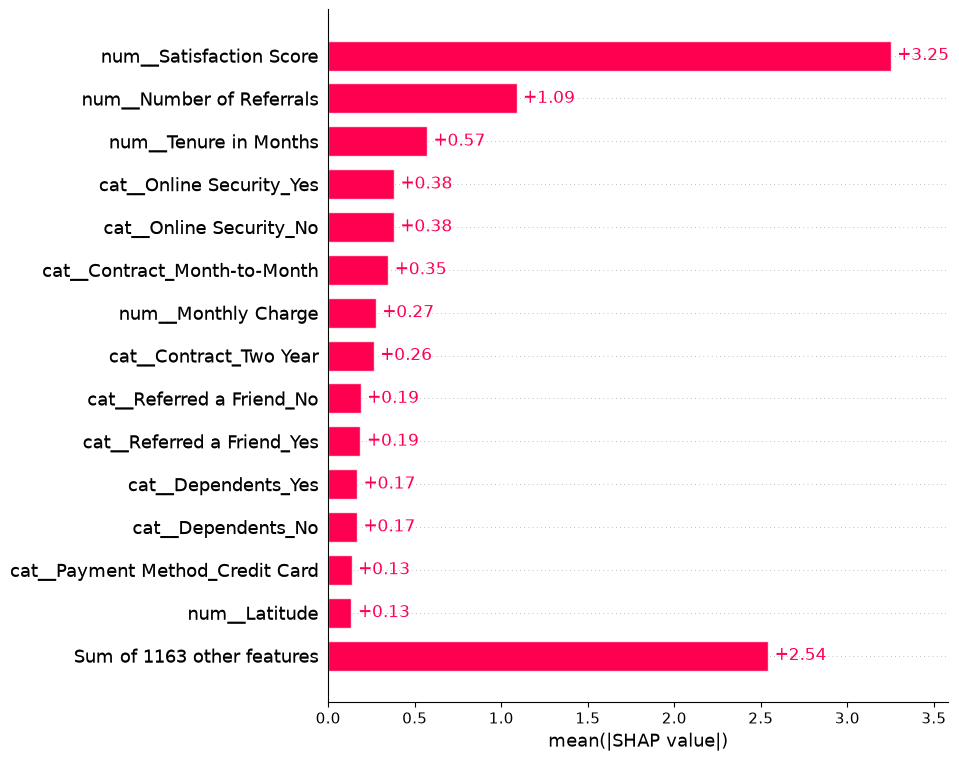

In [7]:
shap.plots.bar(shap_values, max_display=15)


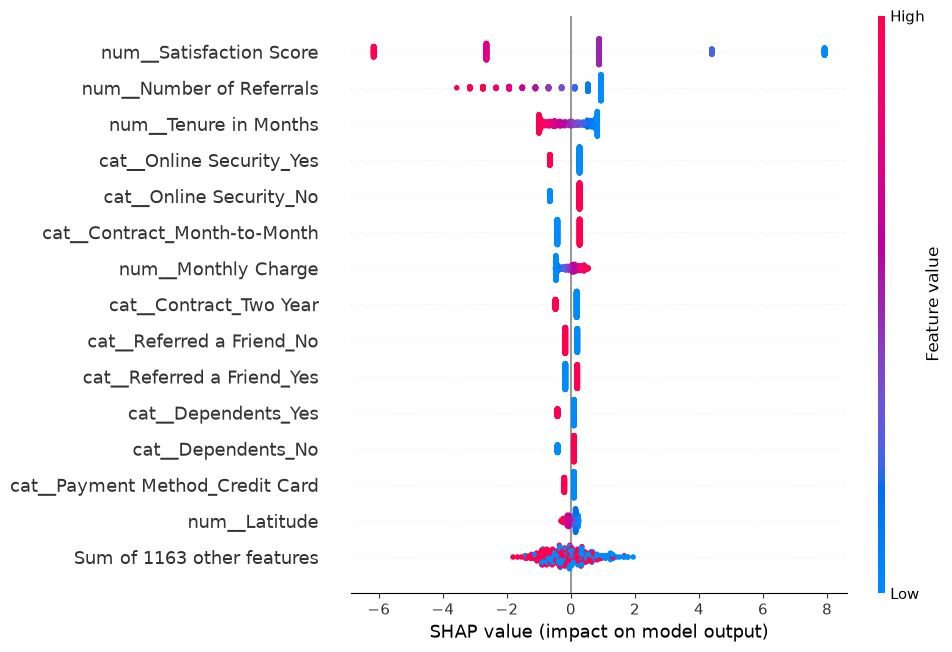

In [8]:
shap.plots.beeswarm(
    shap_values,
    max_display=15
)

In [9]:
X_sample = X.sample(500, random_state=42)

In [10]:
preprocessor = best_model.named_steps["preprocessor"]
classifier = best_model.named_steps["classifier"]

In [11]:
X_sample_transformed = preprocessor.transform(X_sample)

X_sample_transformed.shape

(500, 1177)

In [12]:
customer = X.iloc[[0]]

In [13]:
customer_transformed = preprocessor.transform(customer)

In [14]:
customer_shap = explainer(customer_transformed)

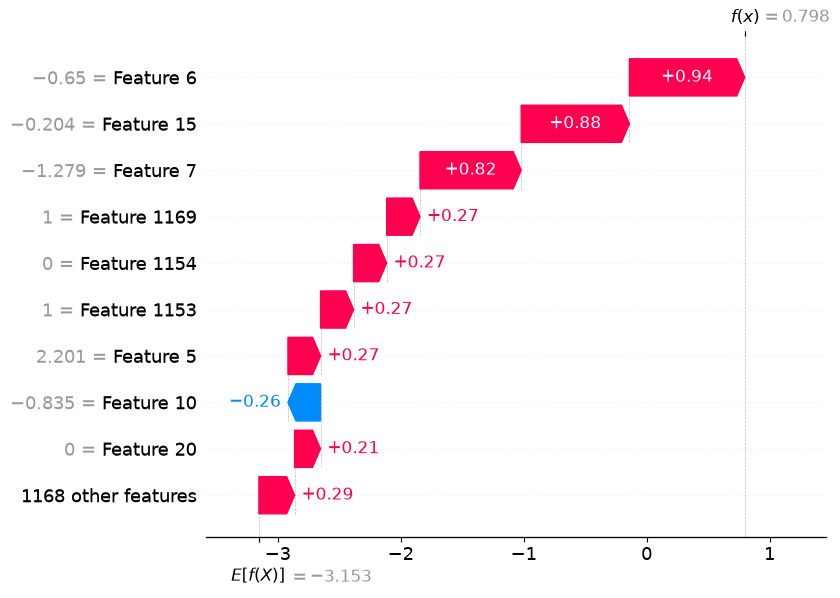

In [15]:
shap.plots.waterfall(customer_shap[0])

In [16]:
prediction = best_model.predict(customer)[0]
probability = best_model.predict_proba(customer)[0][1]
print("Prediction:","Churn"if prediction == 1 else "No Churn")
print("Churn Probability:",round(probability*100,2),"%")

Prediction: Churn
Churn Probability: 68.95 %


In [17]:
importance = pd.DataFrame({
    "feature": shap_values.feature_names,
    "importance": np.abs(shap_values.values).mean(axis=0)
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance.to_csv(
    "../reports/shap_feature_importance.csv",
    index=False
)


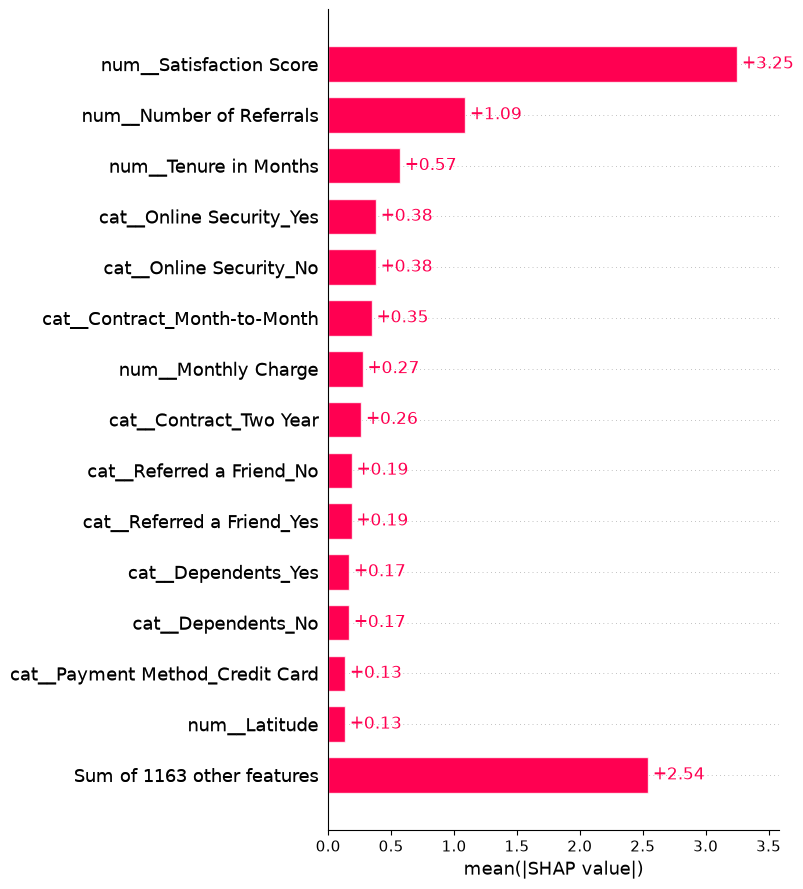

In [18]:
plt.figure()

shap.plots.bar(
    shap_values,
    max_display=15,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../reports/shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
X.iloc[0].to_dict()

{'Gender': 'Male',
 'Age': 78,
 'Under 30': 'No',
 'Senior Citizen': 'Yes',
 'Married': 'No',
 'Dependents': 'No',
 'Number of Dependents': 0,
 'Country': 'United States',
 'State': 'California',
 'City': 'Los Angeles',
 'Zip Code': 90022,
 'Latitude': 34.02381,
 'Longitude': -118.156582,
 'Population': 68701,
 'Quarter': 'Q3',
 'Referred a Friend': 'No',
 'Number of Referrals': 0,
 'Tenure in Months': 1,
 'Offer': nan,
 'Phone Service': 'No',
 'Avg Monthly Long Distance Charges': 0.0,
 'Multiple Lines': 'No',
 'Internet Service': 'Yes',
 'Internet Type': 'DSL',
 'Avg Monthly GB Download': 8,
 'Online Security': 'No',
 'Online Backup': 'No',
 'Device Protection Plan': 'Yes',
 'Premium Tech Support': 'No',
 'Streaming TV': 'No',
 'Streaming Movies': 'Yes',
 'Streaming Music': 'No',
 'Unlimited Data': 'No',
 'Contract': 'Month-to-Month',
 'Paperless Billing': 'Yes',
 'Payment Method': 'Bank Withdrawal',
 'Monthly Charge': 39.65,
 'Total Charges': 39.65,
 'Total Refunds': 0.0,
 'Total Ext

In [20]:
print("Notebook customer shape:", customer.shape)

print("Notebook prediction:",
      best_model.predict(customer)[0])

print("Notebook probability:",
      best_model.predict_proba(customer)[0])

Notebook customer shape: (1, 42)
Notebook prediction: 1
Notebook probability: [0.31045444 0.68954556]


Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


Local SHAP explanation created successfully.
Customer encoded shape: (1, 1177)


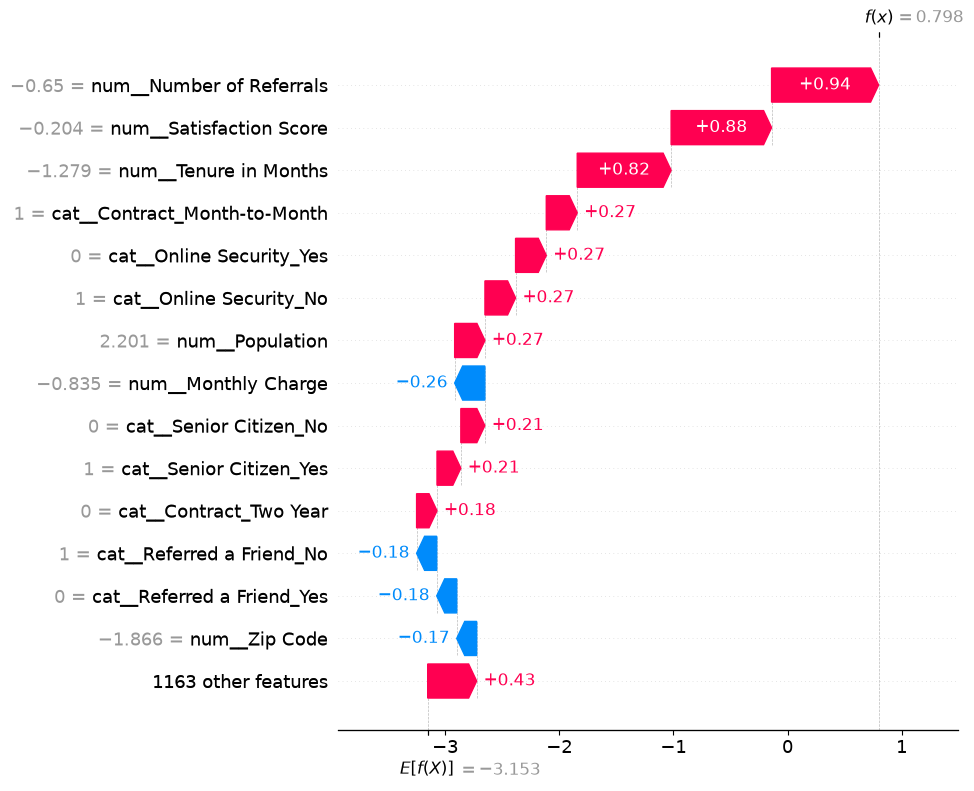

In [22]:
# =========================================================
# LOCAL SHAP EXPLANATION FOR CURRENT CUSTOMER
# =========================================================

# Use the SAME preprocessor and classifier
preprocessor = best_model[:-1]
classifier = best_model[-1]

# ---------------------------------------------------------
# Transform background/sample data
# ---------------------------------------------------------

X_sample = X.sample(500, random_state=42)

X_sample_encoded = preprocessor.transform(X_sample)

if hasattr(X_sample_encoded, "toarray"):
    X_sample_encoded = X_sample_encoded.toarray()

feature_names = preprocessor.get_feature_names_out()

X_sample_encoded_df = pd.DataFrame(
    X_sample_encoded,
    columns=feature_names
)

# ---------------------------------------------------------
# Transform current customer
# ---------------------------------------------------------

customer_encoded = preprocessor.transform(customer)

if hasattr(customer_encoded, "toarray"):
    customer_encoded = customer_encoded.toarray()

customer_encoded_df = pd.DataFrame(
    customer_encoded,
    columns=feature_names
)

# ---------------------------------------------------------
# IMPORTANT:
# Use X_sample as SHAP background,
# NOT the customer itself
# ---------------------------------------------------------

local_explainer = shap.LinearExplainer(
    classifier,
    X_sample_encoded_df
)

# Calculate SHAP values for the customer
local_shap_values = local_explainer(
    customer_encoded_df
)

print("Local SHAP explanation created successfully.")
print("Customer encoded shape:", customer_encoded_df.shape)

# ---------------------------------------------------------
# Waterfall plot
# ---------------------------------------------------------

shap.plots.waterfall(
    local_shap_values[0],
    max_display=15
)

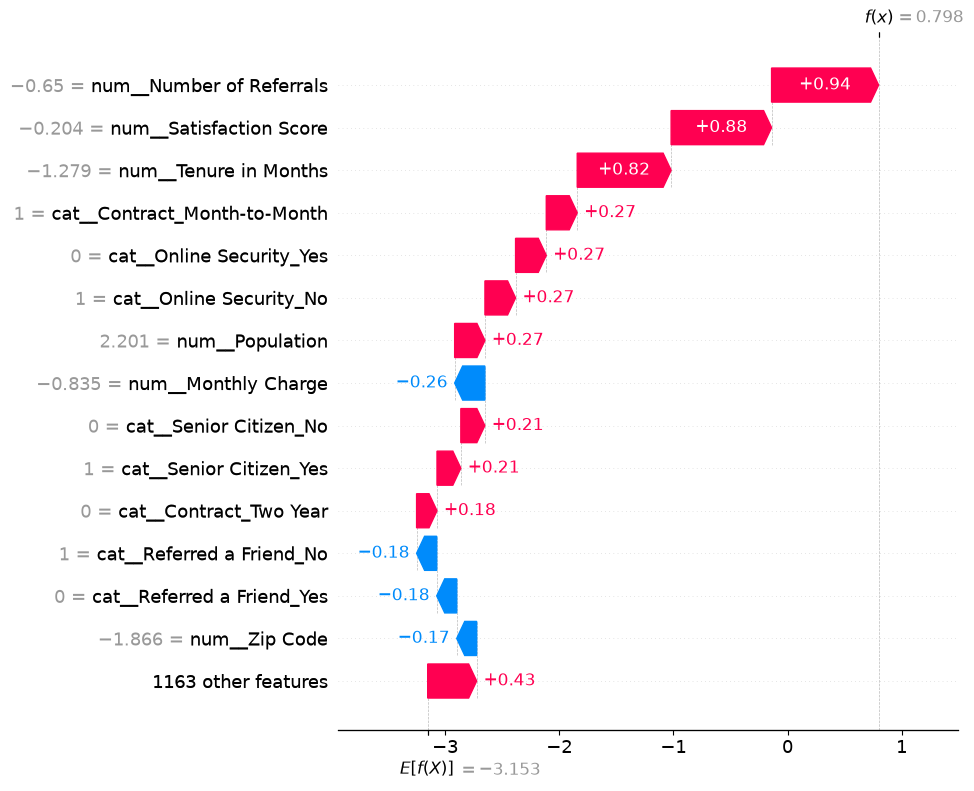

In [23]:
# =========================================================
# LOCAL SHAP WATERFALL PLOT
# =========================================================

shap.plots.waterfall(
    local_shap_values[0],
    max_display=15
)

In [24]:
# =========================================================
# CLEAN LOCAL SHAP EXPLANATION
# =========================================================

# Get SHAP values for our customer
shap_values_array = local_shap_values.values[0]

# Get transformed feature names
feature_names = customer_encoded_df.columns

# Create dataframe
local_importance = pd.DataFrame({
    "encoded_feature": feature_names,
    "shap_value": shap_values_array
})

# ---------------------------------------------------------
# Convert encoded feature names back to original features
# ---------------------------------------------------------

def get_original_feature(feature_name):

    # Remove pipeline prefix
    if "__" in feature_name:
        feature_name = feature_name.split("__", 1)[1]

    # Handle categorical one-hot encoded features
    categorical_features = [
        "Online Security",
        "Online Backup",
        "Device Protection Plan",
        "Premium Tech Support",
        "Streaming TV",
        "Streaming Movies",
        "Streaming Music",
        "Unlimited Data",
        "Contract",
        "Payment Method",
        "Referred a Friend",
        "Dependents",
        "Married",
        "Gender",
        "Internet Service",
        "Internet Type",
        "Phone Service",
        "Multiple Lines",
        "Paperless Billing",
        "Senior Citizen",
        "Under 30",
        "Offer",
        "Quarter"
    ]

    for feature in categorical_features:
        if feature_name.startswith(feature + "_"):
            return feature

    # Numeric feature
    return feature_name


local_importance["original_feature"] = (
    local_importance["encoded_feature"]
    .apply(get_original_feature)
)

# ---------------------------------------------------------
# Combine one-hot encoded features
# ---------------------------------------------------------

aggregated_importance = (
    local_importance
    .groupby("original_feature")["shap_value"]
    .sum()
    .sort_values(key=abs, ascending=False)
)

# Display result
print("Top features influencing this customer's prediction:")
display(aggregated_importance.head(15))

Top features influencing this customer's prediction:


original_feature
Number of Referrals    0.937697
Satisfaction Score     0.880256
Tenure in Months       0.822674
Online Security        0.537404
Contract               0.454283
Senior Citizen         0.419236
Referred a Friend     -0.351606
Phone Service          0.297578
Population             0.265366
Monthly Charge        -0.264574
Married               -0.201679
Dependents             0.184018
Zip Code              -0.174650
Latitude               0.151574
Streaming Music       -0.137479
Name: shap_value, dtype: float64

In [25]:
X_sample = X.sample(500, random_state=42)

In [26]:
local_explainer = shap.LinearExplainer(
    classifier,
    customer_encoded_df
)

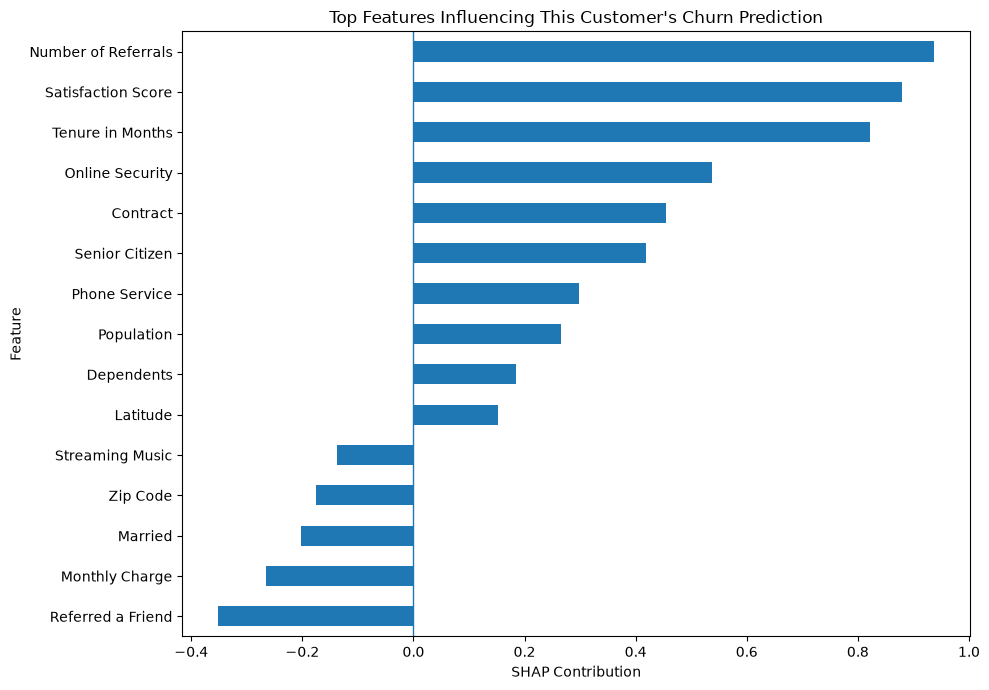

In [27]:
# =========================================================
# CLEAN LOCAL SHAP BAR CHART
# =========================================================

top_features = aggregated_importance.head(15).sort_values()

plt.figure(figsize=(10, 7))

top_features.plot(
    kind="barh"
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel("SHAP Contribution")
plt.ylabel("Feature")

plt.title(
    "Top Features Influencing This Customer's Churn Prediction"
)

plt.tight_layout()

plt.savefig(
    "../reports/local_shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
# =========================================================
# CUSTOMER PREDICTION SUMMARY
# =========================================================

customer_prediction = best_model.predict(customer)[0]

customer_probability = best_model.predict_proba(customer)[0][1]

print("==============================================")
print("CUSTOMER PREDICTION")
print("==============================================")

print(
    "Prediction:",
    "Churn" if customer_prediction == 1 else "No Churn"
)

print(
    f"Churn Probability: {customer_probability * 100:.2f}%"
)

print("==============================================")

CUSTOMER PREDICTION
Prediction: Churn
Churn Probability: 68.95%
